<a href="https://colab.research.google.com/github/Omar-Ahmed-Kandel/Spam-Emails-Detection-/blob/main/Spam_Emails_Detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("purusinghvi/email-spam-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'email-spam-classification-dataset' dataset.
Path to dataset files: /kaggle/input/email-spam-classification-dataset


In [ ]:
df = pd.read_csv('/kaggle/input/email-spam-classification-dataset/combined_data.csv')
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [ ]:
df['label'].value_counts()

,count
label,
1,43910
0,39538


In [ ]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_train_num = vectorizer.fit_transform(X_train)
X_test_num = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_num, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_num)

In [ ]:
print("\n Evaluation Metrics")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


 Evaluation Metrics
Accuracy: 0.986099460754943
Precision: 0.9802705749718151
Recall: 0.9934872029250457
F1 Score: 0.9868346385200317


/tmp/ipython-input-3017221943.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


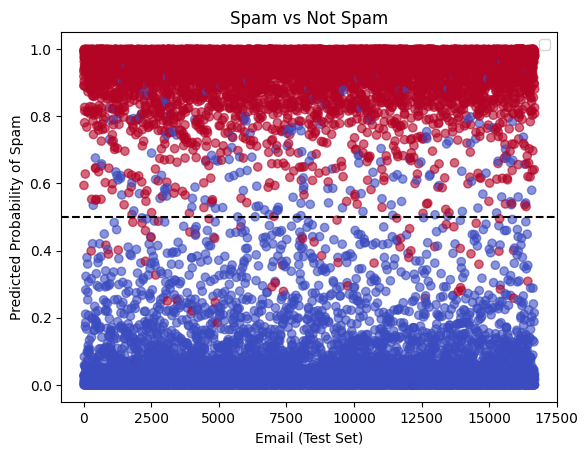

In [ ]:
y_proba = model.predict_proba(X_test_num)[:, 1]

plt.scatter(range(len(y_test)), y_proba, c=y_test, cmap="coolwarm", alpha=0.6)
plt.axhline(0.5, color='black', linestyle='--')
plt.xlabel("Email (Test Set)")
plt.ylabel("Predicted Probability of Spam")
plt.title("Spam vs Not Spam")
plt.legend()
plt.show()


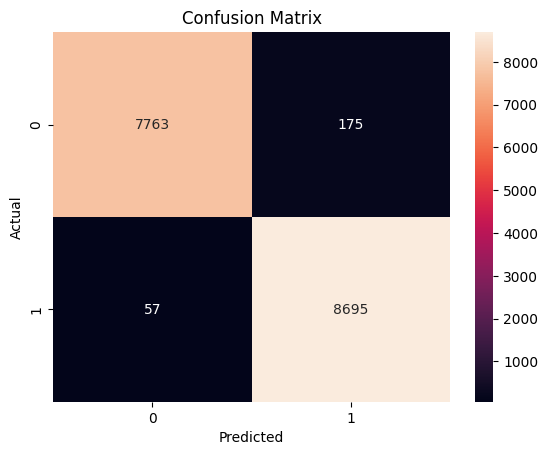

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()